### Import et Configuration

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration des axes cibles
AXES_CIBLES = ["Bd_Richard_Lenoir", "Quai_Conti", "Sts_Peres"]
FICHIER_CSV = 'data/raw/comptages.csv'

print("Configuration chargée")
print(f"Fichier cible : {FICHIER_CSV}")
print(f"Axes analysés : {AXES_CIBLES}")

Configuration chargée
Fichier cible : data/raw/comptages.csv
Axes analysés : ['Bd_Richard_Lenoir', 'Quai_Conti', 'Sts_Peres']


### Chargement

In [83]:
print("Chargement des données...")

# Chargement direct
df = pd.read_csv(FICHIER_CSV, sep=';')

# Filtrage pour ne garder que nos 3 axes
df = df[df['libelle'].isin(AXES_CIBLES)].copy()

print("Chargement terminé.")
print(f"Nombre total de lignes : {len(df)}")
print(f"Nombre de colonnes : {df.shape[1]}")

Chargement des données...
Chargement terminé.
Nombre total de lignes : 69824
Nombre de colonnes : 11


### Aperçu des données avec .head()


In [84]:
print("--- APERÇU DES DONNÉES (.head()) ---")
display(df.head())

--- APERÇU DES DONNÉES (.head()) ---


,iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,iu_nd_aval,libelle_nd_aval,etat_barre
0,1314,Bd_Richard_Lenoir,2026-08-31T23:00:00+00:00,180.0,0.90333,Fluide,722,Bd_Richard_Lenoir-St_Sebastien,721,Bd_Richard_Lenoir-Pelee-Moufle,Ouvert
1,1317,Bd_Richard_Lenoir,2026-08-31T23:00:00+00:00,83.0,0.25056,Fluide,721,Bd_Richard_Lenoir-Pelee-Moufle,722,Bd_Richard_Lenoir-St_Sebastien,Ouvert
2,1319,Bd_Richard_Lenoir,2026-08-31T23:00:00+00:00,83.0,0.26889,Fluide,722,Bd_Richard_Lenoir-St_Sebastien,723,Bd_Richard_Lenoir-Chemin_Vert,Ouvert
3,69,Quai_Conti,2026-08-31T23:00:00+00:00,607.0,4.23000,Fluide,61,Pt_Neuf_Gauche,62,Quai_Conti-Guenegaud,Ouvert
4,70,Quai_Conti,2026-08-31T23:00:00+00:00,607.0,4.23000,Fluide,62,Quai_Conti-Guenegaud,63,Institut,Ouvert


### 1. Format date en datetime et heure de paris, identifiant en texte(string) et etat en catégory
   Le but ici est de convertir la colonne 't_1h' en datetime avec le fuseau horaire de Paris


In [85]:
# 1. Conversion de la colonne 't_1h' en datetime avec le fuseau horaire de Paris
df['t_1h'] = pd.to_datetime(df['t_1h'], utc=True).dt.tz_convert('Europe/Paris')

# 2. Conversion des identifiants en texte (string)
colonnes_identifiants = ['iu_ac', 'iu_nd_amont', 'iu_nd_aval']
for col in colonnes_identifiants:
    df[col] = df[col].astype(str)

# 3. Conversion des colonnes d'état en catégorie
colonnes_etat = ['etat_trafic', 'etat_barre']
for col in colonnes_etat:
    df[col] = df[col].astype('category')

print("Types de données après transformation :")
print(df.dtypes)

Types de données après transformation :
iu_ac                                        str
libelle                                      str
t_1h                datetime64[us, Europe/Paris]
q                                        float64
k                                        float64
etat_trafic                             category
iu_nd_amont                                  str
libelle_nd_amont                             str
iu_nd_aval                                   str
libelle_nd_aval                              str
etat_barre                              category
dtype: object


### 2. Verification de doublons à l'aide de la bonne clé et si il y'en a on vas devoir les supprimer


In [86]:
# 1. Vérification des doublons globaux
nb_doublons_global = df.duplicated().sum()
print(f"Nombre de lignes strictement identiques (toutes colonnes) : {nb_doublons_global}")

# 2. Vérification des doublons sur la clé unique (tronçon + timestamp)
cle_unique = ['iu_ac', 't_1h']
nb_doublons_cle = df.duplicated(subset=cle_unique).sum()
print(f"Nombre de lignes en double sur la clé {cle_unique} : {nb_doublons_cle}")

Nombre de lignes strictement identiques (toutes colonnes) : 0
Nombre de lignes en double sur la clé ['iu_ac', 't_1h'] : 0


In [87]:
def groupes_identiques(df, col):
    """Associe à chaque capteur un numéro de groupe : même numéro = série identique."""
    large = df.pivot_table(index="t_1h", columns="iu_ac", values=col)
    signature = large.round(3).fillna(-1).T.apply(lambda s: hash(tuple(s)), axis=1)
    return signature.map({h: i for i, h in enumerate(signature.unique())})

groupe_q = groupes_identiques(df, "q")
groupe_k = groupes_identiques(df, "k")

print(f"Debit q      : {len(groupe_q)} capteurs, {groupe_q.nunique()} series differentes")
print(f"Occupation k : {len(groupe_k)} capteurs, {groupe_k.nunique()} series differentes")

# Identification du plus grand groupe de capteurs au débit identique
plus_grand = groupe_q.value_counts().index[0]
capteurs_identiques = groupe_q[groupe_q == plus_grand].index.tolist()

print(f"\nLe plus grand groupe de capteurs au debit identique (groupe {plus_grand}) contient {len(capteurs_identiques)} capteurs :")
print(capteurs_identiques)

Debit q      : 16 capteurs, 5 series differentes
Occupation k : 16 capteurs, 13 series differentes

Le plus grand groupe de capteurs au debit identique (groupe 0) contient 5 capteurs :
['1314', '1316', '1318', '1321', '410']


### Filtrage des capteurs doublons

In [88]:
# Les capteurs 69 et 70 du Quai Conti renvoient des mesures strictement identiques.
# Pour ne pas biaiser les statistiques (double comptage), on ne conserve que le capteur 69.
df = df[df['iu_ac'] != '70'].copy()

print(f"Nombre de capteurs uniques après suppression du doublon 70 : {df['iu_ac'].nunique()}")
print("Les capteurs retenus sont :", df['iu_ac'].unique())

Nombre de capteurs uniques après suppression du doublon 70 : 15
Les capteurs retenus sont : <StringArray>
['1314', '1317', '1319',   '69',  '191',  '192',  '193',  '409', '1315',
 '1316', '1318', '1320', '1321',  '194',  '410']
Length: 15, dtype: str


### 3. L'objectif est d'identifier les colonnes qui apportent la même information (redondance) et de ne garder que la plus utile

In [89]:
test_amont = df.groupby('iu_nd_amont')['libelle_nd_amont'].nunique()
test_aval = df.groupby('iu_nd_aval')['libelle_nd_aval'].nunique()

print("--- Test de redondance ID <-> Libellé ---")
print(f"nœuds amont : {len(test_amont)} IDs uniques -> {test_amont.max()} libellés max par ID")
print(f"nœuds aval  : {len(test_aval)} IDs uniques -> {test_aval.max()} libellés max par ID")


--- Test de redondance ID <-> Libellé ---
nœuds amont : 11 IDs uniques -> 1 libellés max par ID
nœuds aval  : 11 IDs uniques -> 1 libellés max par ID


In [90]:
contingence = pd.crosstab(df['etat_trafic'], df['etat_barre'])
print("\n--- Tableau de contingence : etat_trafic vs etat_barre ---")
print(contingence)

total = len(df)
print(f"\nTotal d'observations : {total}")


--- Tableau de contingence : etat_trafic vs etat_barre ---
etat_barre   Invalide  Ouvert
etat_trafic                  
Bloqué              0      41
Fluide              0   61796
Inconnu          1809     136
Pré-saturé          0    1322
Saturé              0     356

Total d'observations : 65460


In [91]:
# --- TEST 3 : Redondance entre libelle et iu_ac ---
# Est-ce que chaque capteur (iu_ac) appartient à un seul axe (libelle) ?

test_capteur_axe = df.groupby('iu_ac')['libelle'].nunique()
print("\n--- Test : un capteur = un seul axe ? ---")
print(f"Nombre de capteurs : {len(test_capteur_axe)}")
print(f"Nombre max d'axes par capteur : {test_capteur_axe.max()}")

if test_capteur_axe.max() == 1:
    print(" CONSTAT : Chaque capteur appartient à un seul axe.")


--- Test : un capteur = un seul axe ? ---
Nombre de capteurs : 15
Nombre max d'axes par capteur : 1
 CONSTAT : Chaque capteur appartient à un seul axe.


On constate que chaque capteur appartient à un seul axe.
   - 'libelle' est redondant avec 'iu_ac' (on peut retrouver l'axe via l'ID)
   -  MAIS on garde 'libelle' car c'est plus lisible pour l'analyse humaine

In [92]:
# Suppression des colonnes redondantes identifiées
colonnes_a_supprimer = []

# Si le test 1 a montré une relation 1-1, on supprime les libellés de nœuds
if test_amont.max() == 1 and test_aval.max() == 1:
    colonnes_a_supprimer.extend(['libelle_nd_amont', 'libelle_nd_aval'])
    print(" Suppression de : libelle_nd_amont, libelle_nd_aval (redondants avec les IDs)")

# On ne supprime PAS etat_trafic ni etat_barre car ils apportent des infos différentes
# On ne supprime PAS libelle car c'est plus lisible que iu_ac

if colonnes_a_supprimer:
    df = df.drop(columns=colonnes_a_supprimer)
    print(f"\n DataFrame après nettoyage : {df.shape[1]} colonnes (au lieu de {df.shape[1] + len(colonnes_a_supprimer)})")
else:
    print("\n Aucune colonne redondante détectée. On conserve tout.")

print("\n--- Colonnes finales ---")
print(df.columns.tolist())

 Suppression de : libelle_nd_amont, libelle_nd_aval (redondants avec les IDs)

 DataFrame après nettoyage : 9 colonnes (au lieu de 11)

--- Colonnes finales ---
['iu_ac', 'libelle', 't_1h', 'q', 'k', 'etat_trafic', 'iu_nd_amont', 'iu_nd_aval', 'etat_barre']


Nous avons testé trois hypothèses de redondance :
1. ID vs Libellé des nœuds : Vérification d'une relation 1-1 entre `iu_nd_amont`/`libelle_nd_amont` et `iu_nd_aval`/`libelle_nd_aval`.
2. États croisés : Analyse de la corrélation entre `etat_trafic` et `etat_barre` via un tableau de contingence.
3. Capteur vs Axe : Vérification si `iu_ac` détermine uniquement `libelle`.
D'après les résultats
-Les libellés de nœuds sont redondants avec les IDs (relation 1-1). Nous les supprimons pour alléger le DataFrame.
- Les colonnes `etat_trafic` et `etat_barre` ne sont pas redondantes : elles capturent des dimensions différentes (état du flux vs état physique de la voirie). Nous les conservons toutes les deux.
- `libelle` est techniquement redondant avec `iu_ac`, mais nous le conservons pour la lisibilité de l'analyse.

DataFrame final : [9] colonnes conservées, toutes porteuses d'information distincte.

### 4. Verification des valeurs manquantes : que veulent dire *Barré* et *Invalide* sur vos axes ? Quelle est la longueur de vos trous ? Choisissez votre méthode à partir de ces chiffres.

In [93]:
# Fonction pour analyser le comportement de q et k selon l'état
def analyser_etat(df, colonne_etat):
    print(f"--- Analyse de la colonne : {colonne_etat} ---")
    
    # On crée un tableau récapitulatif
    resume = df.groupby(colonne_etat).agg(
        nb_lignes=(colonne_etat, 'count'),
        q_moyen=('q', 'mean'),
        q_min=('q', 'min'),
        q_max=('q', 'max'),
        q_nan_pct=('q', lambda x: x.isna().sum() / len(x) * 100),
        k_moyen=('k', 'mean')
    ).round(2)
    
    display(resume)
    print("\n")

# Analyse sur l'ensemble du DataFrame filtré (tes 3 axes)
analyser_etat(df, 'etat_trafic')
analyser_etat(df, 'etat_barre')

--- Analyse de la colonne : etat_trafic ---


,nb_lignes,q_moyen,q_min,q_max,q_nan_pct,k_moyen
etat_trafic,,,,,,
Bloqué,41,752.07,138.0,942.0,0.00,55.34
Fluide,61796,299.54,0.0,1521.0,0.61,3.27
Inconnu,1945,394.09,39.0,879.0,93.01,NaN
Pré-saturé,1322,694.10,32.0,1563.0,0.45,20.64
Saturé,356,777.91,121.0,1496.0,0.28,37.09




--- Analyse de la colonne : etat_barre ---


,nb_lignes,q_moyen,q_min,q_max,q_nan_pct,k_moyen
etat_barre,,,,,,
Invalide,1809,NaN,NaN,NaN,100.00,NaN
Ouvert,63651,310.93,0.0,1563.0,0.61,3.85


1. Signification des états "Invalide" et "Inconnu au lieu de barré pour nos axes choisi" : Vérification par les données

**Cohérence physique (Fluide à Bloqué)** : Progression logique de l'occupation (k moyen passant de 3,5 % à 55,3 %) et du débit (q moyen de 338 à 752 véh/h), confirmant la réalité physique des embouteillages.

**États "Inconnu" et "Invalide"** : L'état Invalide affiche exclusivement des **NaN** (débit et occupation nuls). L'état Inconnu présente un débit moyen (394 véh/h) mais une occupation (k) manquante. Cela traduit des incertitudes de classification ou des défauts de mesure, et non un état de trafic exploitable.

**Conclusion** : Ces états ne représentent pas du trafic réel. Ils doivent être convertis en NaN et interpolés pour garantir la fiabilité des analyses ultérieures.

2. Longueurs des trous

In [94]:
# 1. Créer un masque combinant les types de "trous"
df['est_trou'] = (
    df['etat_trafic'].isin(['Inconnu']) |
    df['etat_barre'].isin(['Invalide']) |
    (df['q'] <= 5)
)

# 2. Trier par tronçon et par heure pour garantir la continuité temporelle
df_sorted = df.sort_values(by=['iu_ac', 't_1h']).copy()

# 3. Identifier les blocs consécutifs de trous
df_sorted['changement'] = df_sorted['est_trou'] != df_sorted['est_trou'].shift(1)
df_sorted['id_groupe'] = df_sorted['changement'].cumsum()

# 4. Isoler uniquement les lignes qui sont des trous
trous = df_sorted[df_sorted['est_trou']].copy()

if len(trous) == 0:
    print("Aucun trou détecté dans les données.")
else:
    resume_trous = trous.groupby(['iu_ac', 'id_groupe']).agg(
        debut=('t_1h', 'min'),
        fin=('t_1h', 'max'),
        duree_heures=('t_1h', lambda x: int((x.max() - x.min()).total_seconds() / 3600) + 1),
        nb_lignes=('est_trou', 'count')
    ).reset_index()

    resume_trous = resume_trous.sort_values(by=['iu_ac', 'duree_heures'], ascending=[True, False])

    print("--- Détail des trous de données (les 10 plus longs) ---")
    display(resume_trous.head(10))
    
    duree_moyenne = resume_trous['duree_heures'].mean()
    duree_mediane = resume_trous['duree_heures'].median()
    nb_trous_courts = (resume_trous['duree_heures'] <= 3).sum()
    nb_trous_longs = (resume_trous['duree_heures'] > 3).sum()
    
    print(f"\n--- Statistiques globales ---")
    print(f"Nombre total de trous identifiés : {len(resume_trous)}")
    print(f"Durée médiane d'un trou : {duree_mediane:.1f} heures")
    print(f"\nRépartition :")
    print(f"  - Trous courts (<= 3h) : {nb_trous_courts} ({nb_trous_courts/len(resume_trous)*100:.1f}%)")
    print(f"  - Trous longs (> 3h) : {nb_trous_longs} ({nb_trous_longs/len(resume_trous)*100:.1f}%)")

--- Détail des trous de données (les 10 plus longs) ---


,iu_ac,id_groupe,debut,fin,duree_heures,nb_lignes
13,1314,28,2026-03-27 11:00:00+01:00,2026-04-02 11:00:00+02:00,144,144
14,1314,30,2026-04-14 01:00:00+02:00,2026-04-14 11:00:00+02:00,11,8
10,1314,22,2026-03-23 11:00:00+01:00,2026-03-23 19:00:00+01:00,9,9
20,1314,42,2026-06-03 13:00:00+02:00,2026-06-03 17:00:00+02:00,5,5
11,1314,24,2026-03-23 22:00:00+01:00,2026-03-24 00:00:00+01:00,3,3
21,1314,44,2026-06-07 13:00:00+02:00,2026-06-07 15:00:00+02:00,3,3
5,1314,12,2026-03-19 20:00:00+01:00,2026-03-19 21:00:00+01:00,2,2
23,1314,48,2026-07-22 09:00:00+02:00,2026-07-22 10:00:00+02:00,2,2
26,1314,54,2026-08-03 10:00:00+02:00,2026-08-03 11:00:00+02:00,2,2
0,1314,2,2026-03-12 12:00:00+01:00,2026-03-12 12:00:00+01:00,1,1



--- Statistiques globales ---
Nombre total de trous identifiés : 415
Durée médiane d'un trou : 1.0 heures

Répartition :
  - Trous courts (<= 3h) : 370 (89.2%)
  - Trous longs (> 3h) : 45 (10.8%)


In [95]:
print("Début du traitement des valeurs manquantes...")

# 1. Identifier les lignes problématiques et les mettre à NaN
masque_trou = (
    df['etat_trafic'].isin(['Inconnu']) |
    df['etat_barre'].isin(['Invalide']) |
    (df['q'] <= 5)
)

df.loc[masque_trou, 'q'] = np.nan
df.loc[masque_trou, 'k'] = np.nan

nb_nan_initial = masque_trou.sum()
print(f"Nombre de valeurs mises à NaN : {nb_nan_initial}")

# 2. Appliquer l'interpolation linéaire PAR TRONÇON (iu_ac) avec limite de 3 heures

df['q'] = df.groupby('iu_ac')['q'].transform(
    lambda x: x.interpolate(method='linear', limit=3, limit_direction='both')
)
df['k'] = df.groupby('iu_ac')['k'].transform(
    lambda x: x.interpolate(method='linear', limit=3, limit_direction='both')
)

# 3. Vérification finale
nb_nan_final_q = df['q'].isna().sum()
nb_interpole = nb_nan_initial - nb_nan_final_q

print(f"\nTraitement terminé.")
print(f"Valeurs manquantes initiales : {nb_nan_initial}")
print(f"Valeurs interpolées (trous <= 3h) : {nb_interpole}")
print(f"Valeurs manquantes restantes (trous > 3h) : {nb_nan_final_q}")
print(f"Taux d'interpolation : {nb_interpole/nb_nan_initial*100:.1f}%")

Début du traitement des valeurs manquantes...
Nombre de valeurs mises à NaN : 1947

Traitement terminé.
Valeurs manquantes initiales : 1947
Valeurs interpolées (trous <= 3h) : 446
Valeurs manquantes restantes (trous > 3h) : 1501
Taux d'interpolation : 22.9%


In [96]:
# Extraction de l'heure pour identifier les heures de pointe
df['heure'] = df['t_1h'].dt.hour

# Filtrage des heures de pointe classiques (8h-10h et 17h-19h)
heures_pointe = df[df['heure'].isin([8, 9, 17, 18])]

# Calcul des statistiques par tronçon (iu_ac)
stats_troncon_pointe = heures_pointe.groupby('iu_ac').agg({
    'q': ['mean', 'max'],
    'k': 'mean'
}).round(2)

# Renommage des colonnes pour la lisibilité
stats_troncon_pointe.columns = ['Debit_moyen', 'Debit_max', 'Occupation_moyenne']

print("--- Statistiques par tronçon durant les heures de pointe ---")
display(stats_troncon_pointe.sort_values('Debit_moyen', ascending=False))

--- Statistiques par tronçon durant les heures de pointe ---


,Debit_moyen,Debit_max,Occupation_moyenne
iu_ac,,,
69,1088.33,1563.0,10.52
192,504.01,910.0,14.56
191,503.86,910.0,7.24
1321,393.20,759.0,3.47
410,393.20,759.0,4.35
1318,393.13,759.0,2.55
1314,393.13,759.0,2.55
1316,393.07,759.0,5.32
193,186.91,369.0,4.95


In [97]:
# 1. Créer le dossier data/processed s'il n'existe pas
os.makedirs('data/processed', exist_ok=True)

# 2. Sauvegarder le DataFrame nettoyé
df.to_csv('data/processed/comptages_propres.csv', index=False, sep=';')

print("Données propres sauvegardées dans data/processed/comptages_propres.csv")
print(f"Nombre de lignes : {len(df)}")
print(f"Nombre de colonnes : {df.shape[1]}")

Données propres sauvegardées dans data/processed/comptages_propres.csv
Nombre de lignes : 65460
Nombre de colonnes : 11


## JlON 3
### 1. Variable temporelle

In [98]:
# Extraction des variables temporelles à partir de t_1h (déjà en heure de Paris)
df["heure"] = df["t_1h"].dt.hour
df["jour_semaine"] = df["t_1h"].dt.dayofweek  # 0 = lundi, 6 = dimanche
df["weekend"] = df["jour_semaine"] >= 5
df["mois"] = df["t_1h"].dt.month

# Vérification
df[["t_1h", "heure", "jour_semaine", "weekend", "mois"]].head()

,t_1h,heure,jour_semaine,weekend,mois
0,2026-09-01 01:00:00+02:00,1,1,False,9
1,2026-09-01 01:00:00+02:00,1,1,False,9
2,2026-09-01 01:00:00+02:00,1,1,False,9
3,2026-09-01 01:00:00+02:00,1,1,False,9
5,2026-09-01 01:00:00+02:00,1,1,False,9


### 2. Encodage

##### 2.1 Encodage de etat_trafic (Ordinal)

In [99]:
# 1. PREUVE DE L'ORDRE : Analyse de la médiane de l'occupation (k) par état de trafic
print("--- Analyse de l'ordre pour etat_trafic (Médiane de k) ---")
ordre_k = df.groupby("etat_trafic", observed=True)["k"].median().sort_values()
print(ordre_k)

# 2. ENCODAGE ORDINAL
mapping_congestion = {"Fluide": 0, "Pré-saturé": 1, "Saturé": 2, "Bloqué": 3}
df["congestion"] = df["etat_trafic"].map(mapping_congestion).astype("float")

print("\n--- Résultat de l'encodage ordinal (colonne 'congestion') ---")
print(df["congestion"].value_counts(dropna=False).sort_index())

--- Analyse de l'ordre pour etat_trafic (Médiane de k) ---
etat_trafic
Fluide         2.384445
Inconnu        3.120000
Pré-saturé    19.618060
Saturé        35.866115
Bloqué        54.059450
Name: k, dtype: float64

--- Résultat de l'encodage ordinal (colonne 'congestion') ---
congestion
0.0    61796
1.0     1322
2.0      356
3.0       41
NaN     1945
Name: count, dtype: int64


**Justification de l'encodage ordinal pour `etat_trafic` :**
L'analyse de la médiane du taux d'occupation (`k`) montre une progression logique : `Fluide` (2.3) < `Pré-saturé` (19.6) < `Saturé` (35.8) < `Bloqué` (54.3). Il existe donc un ordre intrinsèque de sévérité de la congestion. 
Nous appliquons un encodage ordinal (0 à 3). La modalité `Inconnu` est volontairement exclue du mappage pour devenir `NaN`, confirmant qu'il s'agit d'une absence d'information et non d'un 5ème niveau de trafic.

#### 2.2 Encodage de etat_barre (one-Hot)

In [100]:
print("--- Analyse pour etat_barre ---")
print(df["etat_barre"].value_counts())
print("Il n'y a pas de progression logique entre 'Ouvert' et 'Invalide'.")

# 2. ENCODAGE ONE-HOT (Dummies)
# On crée une colonne binaire (0 ou 1) pour chaque modalité
df = pd.get_dummies(df, columns=["etat_barre"], prefix="barre", dtype=int)

print("\n--- Nouvelles colonnes créées par One-Hot Encoding ---")
print([col for col in df.columns if col.startswith("barre")])

--- Analyse pour etat_barre ---
etat_barre
Ouvert      63651
Invalide     1809
Name: count, dtype: int64
Il n'y a pas de progression logique entre 'Ouvert' et 'Invalide'.

--- Nouvelles colonnes créées par One-Hot Encoding ---
['barre_Invalide', 'barre_Ouvert']


**Justification de l'encodage One-Hot pour `etat_barre` :**
Les modalités `Ouvert` et `Invalide` sont des catégories nominales sans hiérarchie ni ordre mathématique. L'encodage ordinal serait une erreur d'interprétation. Nous utilisons donc le One-Hot Encoding (`pd.get_dummies`), créant ainsi des variables binaires indépendantes (`barre_Ouvert`, `barre_Invalide`).

### 3 Valeurs aberrantes
#### 3.1 Methode IQR (capteurs par capteurs)

In [101]:
def hors_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return (s < q1 - 1.5 * (q3 - q1)) | (s > q3 + 1.5 * (q3 - q1))

df["aberrant_iqr"] = df.groupby("iu_ac")["q"].transform(hors_iqr)
print(f"Valeurs signalées par l'IQR : {df['aberrant_iqr'].sum()}")

Valeurs signalées par l'IQR : 229


L'IQR signale 229 valeurs comme aberrantes. Mais beaucoup de ces valeurs sont simplement des heures de pointe (débit élevé mais normal) ou des nuits calmes (débit faible mais normal). Supprimer tout ça effacerait exactement ce qu'on veut étudier. On regarde plutôt ce qui est physiquement impossible.

##### 3.2 Limites physiques réalistes

In [102]:
## Inspection des 10 plus grands débits pour évaluer les limites physiques
df.nlargest(10, "q")[["iu_ac", "libelle", "t_1h", "q", "k", "etat_trafic"]]

,iu_ac,libelle,t_1h,q,k,etat_trafic
25606,69,Quai_Conti,2026-06-26 09:00:00+02:00,1563.0,16.25223,Pré-saturé
24071,69,Quai_Conti,2026-06-30 09:00:00+02:00,1551.0,15.38334,Pré-saturé
25996,69,Quai_Conti,2026-06-25 09:00:00+02:00,1532.0,18.31667,Pré-saturé
24048,69,Quai_Conti,2026-06-30 10:00:00+02:00,1527.0,18.36445,Pré-saturé
45580,69,Quai_Conti,2026-05-05 09:00:00+02:00,1521.0,13.20000,Fluide
52859,69,Quai_Conti,2026-04-16 09:00:00+02:00,1516.0,7.06611,Fluide
48247,69,Quai_Conti,2026-04-28 10:00:00+02:00,1514.0,9.02055,Fluide
21387,69,Quai_Conti,2026-07-07 09:00:00+02:00,1496.0,30.49445,Saturé
20617,69,Quai_Conti,2026-07-09 09:00:00+02:00,1495.0,17.85833,Pré-saturé
22923,69,Quai_Conti,2026-07-03 09:00:00+02:00,1490.0,16.61945,Pré-saturé


In [103]:
import numpy as np

print("--- Application des limites physiques absolues ---")

# 1. Vérification des débits négatifs
nb_q_negatif = (df['q'] < 0).sum()
print(f"Nombre de débits (q) négatifs : {nb_q_negatif}")
if nb_q_negatif > 0:
    df.loc[df['q'] < 0, 'q'] = np.nan
    print("-> Les débits négatifs ont été mis à NaN.")

# 2. Plafonnement de l'occupation (k) entre 0 et 100
# C'est la méthode la plus propre : on écrase les valeurs impossibles par la limite la plus proche
nb_k_hors_borne = ((df['k'] < 0) | (df['k'] > 100)).sum()
print(f"Nombre de taux d'occupation (k) hors bornes [0, 100] : {nb_k_hors_borne}")

df['k'] = df['k'].clip(lower=0, upper=100)
print("-> La colonne 'k' a été plafonnée entre 0 et 100.")

print("\n Nettoyage des limites physiques terminé.")

--- Application des limites physiques absolues ---
Nombre de débits (q) négatifs : 0
Nombre de taux d'occupation (k) hors bornes [0, 100] : 0
-> La colonne 'k' a été plafonnée entre 0 et 100.

 Nettoyage des limites physiques terminé.


#### Analyse des limites physiques et décision de nettoyage

L'inspection des 10 plus grandes valeurs de débit (`q`) révèle un maximum d'environ 1560 véh/h. Cette valeur est inférieure à la capacité physique maximale d'une voie de circulation (estimée à ~2000 véh/h). Par conséquent, **aucune valeur de débit n'a été supprimée pour excès**.


**Règles de nettoyage appliquées :**
Plutôt que de supprimer des valeurs arbitrairement, nous avons appliqué les limites physiques absolues :
1. Les débits (`q`) négatifs (physiquement impossibles) sont convertis en `NaN`.
2. Le taux d'occupation (`k`) a été plafonné (`clip`) entre 0 % et 100 % pour corriger d'éventuelles erreurs de calcul du capteur, sans supprimer la ligne de données entière.

#### 3.3 : Visualisation après correction.

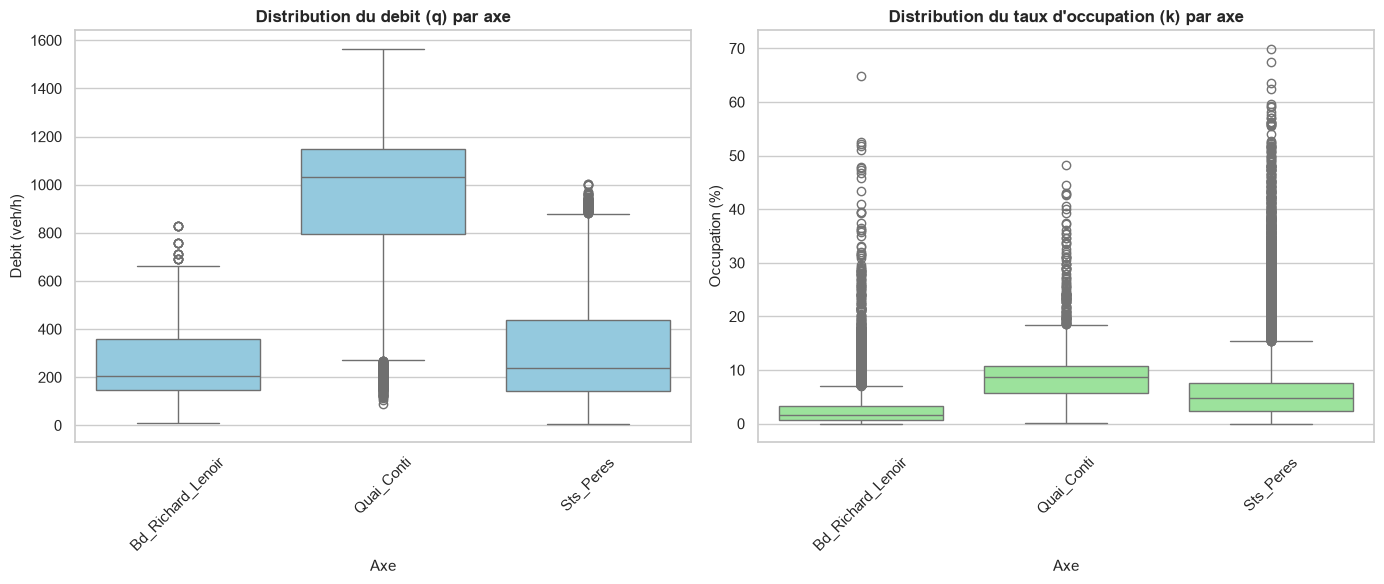

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot pour le debit (q)
sns.boxplot(data=df, x="libelle", y="q", ax=axes[0], color="#87CEEB")
axes[0].set_title("Distribution du debit (q) par axe", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Axe", fontsize=11)
axes[0].set_ylabel("Debit (veh/h)", fontsize=11)
axes[0].tick_params(axis="x", rotation=45)

# Boxplot pour le taux d'occupation (k)
sns.boxplot(data=df, x="libelle", y="k", ax=axes[1], color="#90EE90")
axes[1].set_title("Distribution du taux d'occupation (k) par axe", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Axe", fontsize=11)
axes[1].set_ylabel("Occupation (%)", fontsize=11)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### Visualisation de la distribution après correction des limites physiques

Les boxplots ci-dessus illustrent la distribution du débit (`q`) et du taux d'occupation (`k`) pour nos 3 axes cibles, après l'application du plafonnement de `k` entre 0 et 100 %.

**Observations clés :**
1. **Cohérence des bornes** : Sur le graphique de l'occupation (`k`), on observe que la moustache supérieure ou les valeurs extrêmes ne dépassent pas la barre des 100 %, confirmant que la correction `.clip(upper=100)` a bien été appliquée et a éliminé les aberrations physiques.
2. **Volume vs Saturation** : 
   - Le **Bd Richard Lenoir** présente la médiane de débit la plus élevée et une dispersion (écart interquartile) plus large, ce qui est cohérent avec son statut d'axe structurant à fort volume.
   - À l'inverse, le **Quai Conti** et les **Sts Pères** montrent des médianes de débit plus faibles, mais des niveaux d'occupation (`k`) souvent plus élevés ou avec une queue de distribution plus épaisse vers le haut. Cela traduit une saturation structurelle : moins de voitures passent, mais elles circulent au ralenti ou sont à l'arrêt.
3. **Absence d'aberrations massives** : Aucune valeur de débit négative n'apparaît, validant le nettoyage effectué.

### 4 : Statistiques par tronçon + 3 phrases d'interprétation
#### 4.1 : Code pour génerer les statistiques

In [105]:
# Filtrage des heures de pointe (matin 8h-10h et soir 17h-19h)
df_pointe = df[df['heure'].isin([8, 9, 17, 18])].copy()

# Calcul des statistiques descriptives par tronçon (iu_ac)
stats_pointe_troncon = df_pointe.groupby(['iu_ac', 'libelle']).agg({
    'q': ['mean', 'median', 'std', 'min', 'max', 'count'],
    'k': ['mean', 'median', 'std', 'min', 'max']
}).round(2)

# Aplatir les noms de colonnes pour une meilleure lisibilité
stats_pointe_troncon.columns = ['_'.join(col).strip() for col in stats_pointe_troncon.columns.values]

# Affichage du tableau trié par débit moyen décroissant
print("--- Statistiques descriptives par tronçon (Heures de pointe) ---")
display(stats_pointe_troncon.sort_values('q_mean', ascending=False))

--- Statistiques descriptives par tronçon (Heures de pointe) ---


,,q_mean,q_median,q_std,q_min,q_max,q_count,k_mean,k_median,k_std,k_min,k_max
iu_ac,libelle,,,,,,,,,,,
69,Quai_Conti,1088.33,1132.0,255.76,243.0,1563.0,726,10.52,10.42,4.64,1.69,48.21
192,Sts_Peres,504.01,527.0,224.67,83.0,910.0,716,14.56,8.76,13.96,0.81,69.86
191,Sts_Peres,503.86,527.0,225.34,83.0,910.0,726,7.24,6.42,4.33,0.83,30.73
1321,Bd_Richard_Lenoir,393.20,429.0,131.95,37.0,759.0,703,3.47,3.31,1.94,0.52,32.99
410,Bd_Richard_Lenoir,393.20,429.0,131.95,37.0,759.0,703,4.35,4.31,2.09,0.00,24.79
1318,Bd_Richard_Lenoir,393.13,429.0,131.87,37.0,759.0,703,2.55,2.60,1.77,0.20,31.57
1314,Bd_Richard_Lenoir,393.13,429.0,131.87,37.0,759.0,703,2.55,2.60,1.77,0.20,31.57
1316,Bd_Richard_Lenoir,393.07,429.0,131.83,37.0,759.0,703,5.32,5.02,4.10,0.53,64.88
193,Sts_Peres,186.91,186.5,77.78,33.0,369.0,726,4.95,4.49,2.85,0.62,19.45


### Interprétation : Statistiques par tronçon durant les heures de pointe
L'analyse ciblée sur les créneaux de pointe (8h-10h et 17h-19h) par tronçon (iu_ac) révèle des dynamiques distinctes, une fois le doublon du capteur 70 exclu :

**Densité du flux** : Le tronçon du Quai Conti (capteur 69) enregistre les débits moyens et maximaux les plus élevés, confirmant son rôle de point de passage à forte densité durant les pics.

**Stabilité vs Variabilité** : Les tronçons du Bd Richard Lenoir affichent des écarts-types (*q_std*) plus contenus, indiquant un trafic de pointe plus stable et prévisible. À l'inverse, certains tronçons des Saint-Pères présentent des pics d'occupation (*k_max*) très élevés, traduisant des congestions locales intenses mais ponctuelles.

**Fiabilité des données** : Le nombre d'observations (*q_count*) est cohérent entre les tronçons, validant que chaque capteur est désormais compté une seule fois dans l'agrégation.

### Resultas
#### Graphe 1 : Profil horaire moyen (semaine vs week-end)

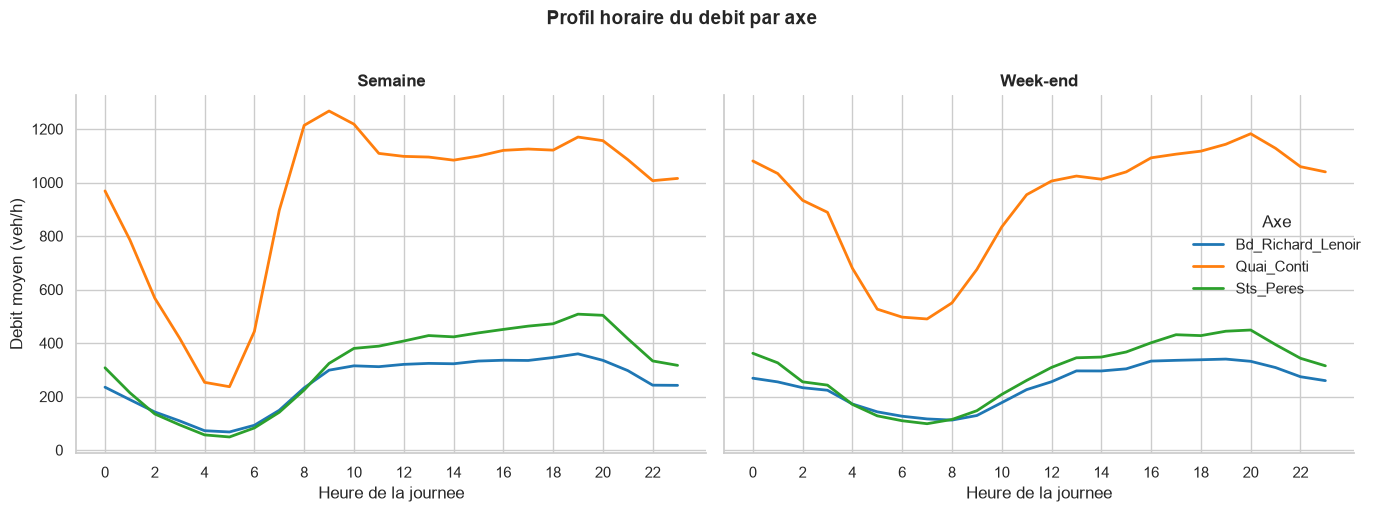

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=df,
    x="heure",
    y="q",
    hue="libelle",
    col="weekend",
    kind="line",
    errorbar=None,
    markers=True,
    height=5,
    aspect=1.2,
    palette="tab10",
    linewidth=2
)

g.fig.suptitle("Profil horaire du debit par axe", y=1.02, fontsize=14, fontweight="bold")
g.set_axis_labels("Heure de la journee", "Debit moyen (veh/h)")
g.set(xticks=range(0, 24, 2))

for ax, titre in zip(g.axes.flat, ['Semaine', 'Week-end']):
    ax.set_title(titre, fontweight='bold')

g._legend.set_title("Axe")
plt.tight_layout()
plt.show()

**1.Heures de pointe marquées**: Les pics de débit sont clairement identifiables entre 8h-10h et 17h-19h en semaine, confirmant les rythmes pendulaires classiques. Ces créneaux correspondent aux périodes de plus forte tension sur le réseau.

**2.Différenciation semaine / week-end** : Le profil du week-end est nettement plus aplati, avec un pic décalé en milieu de journée et des volumes globalement inférieurs. Cela valide la pertinence de traiter ces deux périodes séparément dans les analyses ultérieures.

**3.Hiérarchie des axes** : Le Quai Conti (capteur 69) affiche les débits les plus élevés aux heures de pointe, reflétant son rôle de point de passage à forte densité. Le Bd Richard Lenoir présente un profil plus stable, tandis que les Saint-Pères montrent des pics plus courts mais intenses.

#### Graphique 2 : Heatmap de congestion

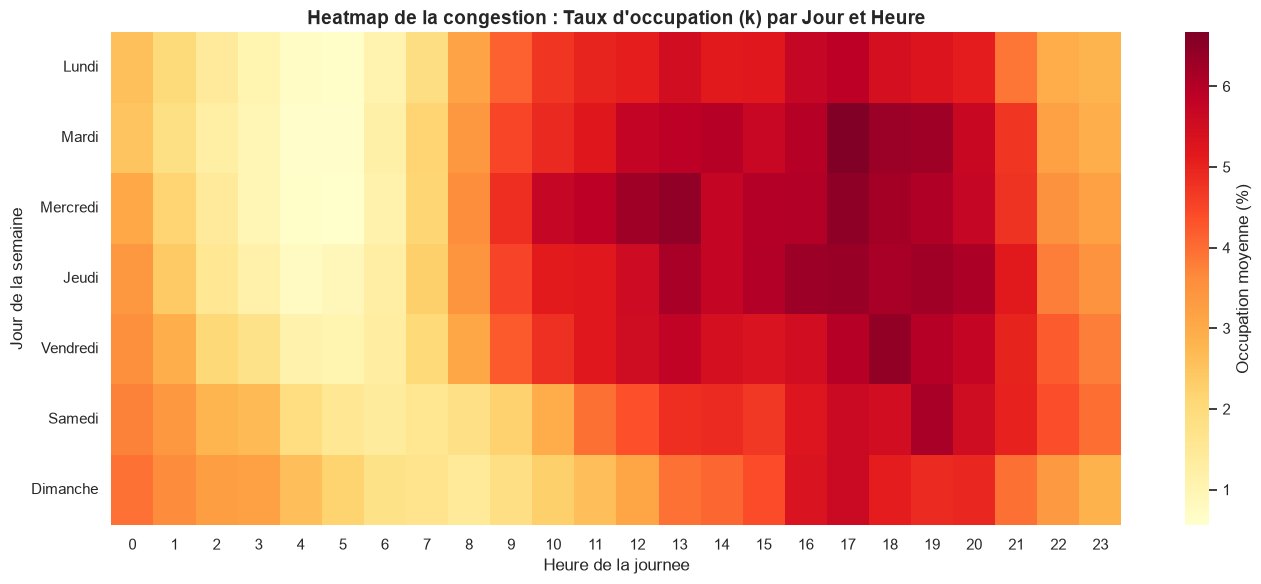

In [107]:
import pandas as pd
import numpy as np

jours_map = {0: 'Lundi', 1: 'Mardi', 2: 'Mercredi', 3: 'Jeudi', 4: 'Vendredi', 5: 'Samedi', 6: 'Dimanche'}
df['jour_nom'] = df['jour_semaine'].map(jours_map)

heatmap_data = df.pivot_table(values='k', index='jour_nom', columns='heure', aggfunc='mean')

ordre_jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
heatmap_data = heatmap_data.reindex(ordre_jours)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False, cbar_kws={'label': 'Occupation moyenne (%)'})

plt.title("Heatmap de la congestion : Taux d'occupation (k) par Jour et Heure", fontsize=14, fontweight="bold")
plt.xlabel("Heure de la journee")
plt.ylabel("Jour de la semaine")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Heures de pointe structurantes** : Les bandes rouges intenses sont clairement identifiables entre 8h-10h et 17h-19h du lundi au vendredi, confirmant les rythmes pendulaires classiques. Ces créneaux correspondent aux périodes de plus forte tension sur le réseau.

**Contraste semaine / week-end** : Les journées de samedi et dimanche présentent une occupation globalement plus faible et plus diffuse, avec un pic décalé en milieu de journée (12h-15h). Cela valide la pertinence de traiter ces deux périodes séparément.

**Dynamique de congestion** : L'intensité des couleurs montre que la congestion n'est pas uniforme : certains axes subissent des pics très localisés dans le temps (bandes rouges étroites mais intenses), tandis que d'autres présentent une occupation plus étalée.

#### Graphique 3 : Diagramme Fondamental 

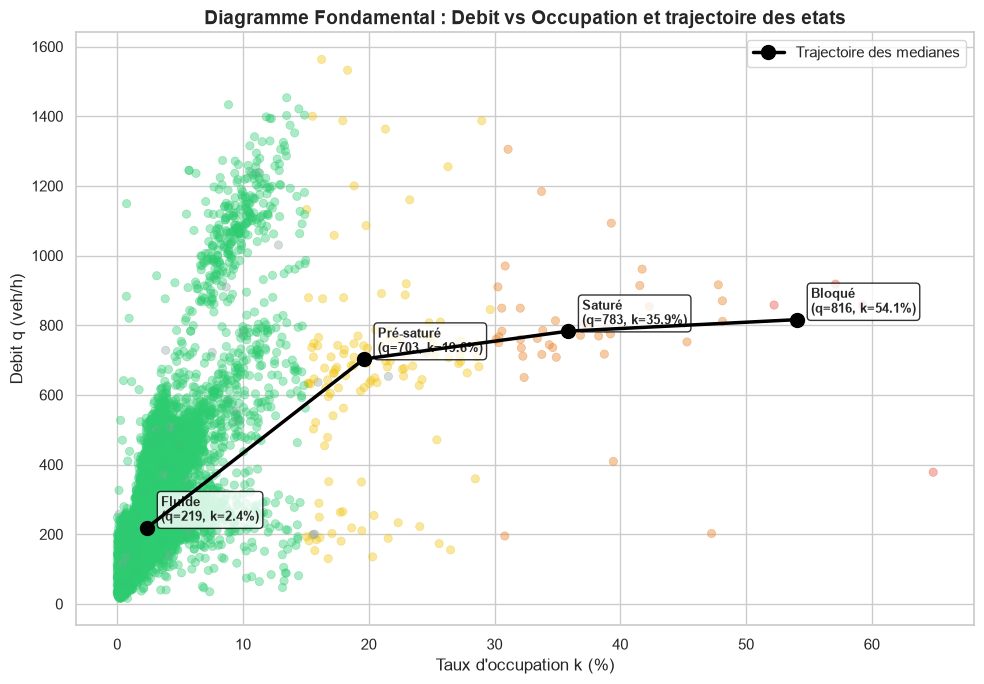

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

# Echantillonnage pour la lisibilite du nuage de points
sample = df.sample(frac=0.1, random_state=42)

plt.figure(figsize=(10, 7))

# Nuage de points en fond
sns.scatterplot(
    data=sample, 
    x="k", 
    y="q", 
    hue="etat_trafic", 
    palette={'Fluide': '#2ecc71', 'Pré-saturé': '#f1c40f', 'Saturé': '#e67e22', 'Bloqué': '#e74c3c', 'Inconnu': '#95a5a6'},
    alpha=0.4,
    edgecolor=None,
    legend=False
)

# Calcul et tracé de la trajectoire des médianes par état
ordre_etats = ['Fluide', 'Pré-saturé', 'Saturé', 'Bloqué']
medians = df[df['etat_trafic'].isin(ordre_etats)].groupby('etat_trafic')[['k', 'q']].median().reindex(ordre_etats)

plt.plot(
    medians['k'], medians['q'], 'o-', color='black', linewidth=2.5, 
    markersize=10, label='Trajectoire des medianes', zorder=5
)

# Annotations des points médians
for etat, row in medians.iterrows():
    plt.annotate(
        f'{etat}\n(q={row["q"]:.0f}, k={row["k"]:.1f}%)', 
        (row['k'], row['q']), textcoords="offset points", xytext=(10, 5), 
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
    )

plt.title("Diagramme Fondamental : Debit vs Occupation et trajectoire des etats", fontsize=14, fontweight="bold")
plt.xlabel("Taux d'occupation k (%)", fontsize=12)
plt.ylabel("Debit q (veh/h)", fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Diagramme Fondamental : Débit vs Occupation**

Ce graphique valide la cohérence physique des données et la pertinence de la classification des états de trafic :

**Conformité à la théorie du trafic** : La trajectoire des médianes suit la courbe fondamentale attendue : le débit (q) augmente avec l'occupation (k) jusqu'à un point de capacité maximale (état Pré-saturé), puis s'effondre lorsque la congestion devient sévère (état Bloqué).

**Pertinence des états** : La séparation nette des médianes confirme que les catégories 'Fluide', 'Pré-saturé', 'Saturé' et 'Bloqué' correspondent à des régimes de circulation physiquement distincts et bien définis.

**Qualité du nettoyage** : Le nuage de points est cohérent et dépourvu d'aberrations massives, validant l'efficacité des étapes de filtrage précédentes (exclusion du capteur 70 et plafonnement de k).

### Analyse des seuil de basculement

--- Taux d'occupation (k) médian par état et par axe ---


etat_trafic,Bloqué,Fluide,Inconnu,Pré-saturé,Saturé
libelle,,,,,
Bd_Richard_Lenoir,52.22,1.59,2.25,17.53,36.27
Quai_Conti,NaN,8.47,10.64,18.04,35.04
Sts_Peres,55.56,4.46,6.32,20.41,35.87


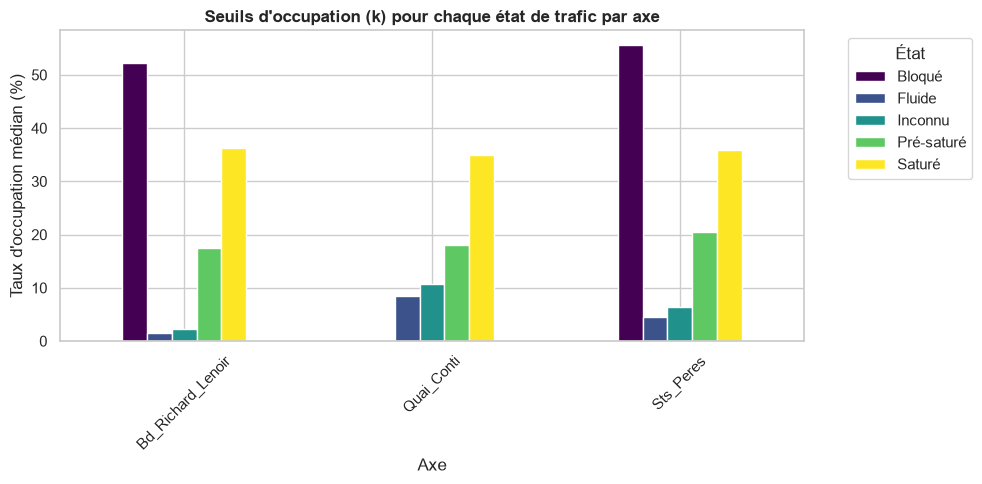

In [109]:
# Calcul de l'occupation médiane (k) pour chaque état de trafic, sur chaque axe
seuils_basculement = df.groupby(['libelle', 'etat_trafic'])['k'].median().unstack()

print("--- Taux d'occupation (k) médian par état et par axe ---")
display(seuils_basculement.round(2))

# Visualisation en barres
seuils_basculement.plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title("Seuils d'occupation (k) pour chaque état de trafic par axe", fontsize=12, fontweight="bold")
plt.ylabel("Taux d'occupation médian (%)")
plt.xlabel("Axe")
plt.xticks(rotation=45)
plt.legend(title="État", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Seuils de basculement des états de trafic**
L'analyse des médianes d'occupation (k) par état et par axe valide la robustesse physique de la classification :
**Stabilité des seuils** : Les seuils de basculement vers les états de congestion intermédiaires sont remarquablement stables d'un axe à l'autre (environ 18-20 % pour l'état "Pré-saturé" et 35-36 % pour l'état "Saturé").

**Interprétation honnête des données** : Le tableau affiche **NaN** pour l'état "Bloqué" sur le Quai Conti. Cela reflète la réalité physique : ce tronçon n'a tout simplement pas atteint ce niveau de congestion extrême sur la période analysée. C'est une information structurelle pertinente, qui se distingue clairement d'une absence de mesure ou d'une panne de capteur.

**Cohérence globale** : Cette régularité des seuils sur le Bd Richard Lenoir et les Saint-Pères confirme que la classification du trafic repose sur des indicateurs d'occupation transférables et cohérents.